# Comparación de modelos

Carga los resultados guardados por cada notebook individual y genera la tabla y figura final.

In [6]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
RESULTS_BASE = '../results'
K_VALUES = [5, 10, 20]

## 1. Cargar todos los resultados

In [7]:
MODELS = ['random', 'mostpopular', 'svd', 'textcf', 'visualcf', 'mmgcn_tmc', "mmgcn"]
DISPLAY_NAMES = {
    'random': 'Random',
    'mostpopular': 'MostPopular',
    'svd': 'SVD',
    'textcf': 'TextCF',
    'visualcf': 'VisualCF (CLIP)',
    'mmgcn_tmc': 'MMGCN-TMC',
    'mmgcn': 'MMGCN'
}

all_metrics = {}
for model in MODELS:
    path = os.path.join(RESULTS_BASE, model, 'metrics.csv')
    if os.path.exists(path):
        df = pd.read_csv(path, index_col='K')
        all_metrics[DISPLAY_NAMES[model]] = df
        print(f'{DISPLAY_NAMES[model]} está listo')
    else:
        print(f'No se encontró el archivo de métricas para {DISPLAY_NAMES[model]} en {path}')

Random está listo
MostPopular está listo
SVD está listo
TextCF está listo
VisualCF (CLIP) está listo
MMGCN-TMC está listo
MMGCN está listo


## 2. Tabla resumen en K=10

In [8]:
METRIC_LABELS = {
    'precision': 'Precision', 'recall': 'Recall', 'ndcg': 'NDCG',
    'novelty': 'Novelty', 'coverage': 'Coverage', 'ild': 'ILD',
}
rows = []
for name, df in all_metrics.items():
    row = df.loc[10].to_dict()
    row['model'] = name
    rows.append(row)

summary = pd.DataFrame(rows).set_index('model')
cols = [c for c in METRIC_LABELS if c in summary.columns]
summary = summary[cols]
summary.columns = [f'{METRIC_LABELS[c]}@10' for c in cols]
sort_col = 'NDCG@10' if 'NDCG@10' in summary.columns else summary.columns[0]
summary = summary.sort_values(sort_col, ascending=False)

print('=== Tabla comparativa K=10 ===')
print(summary.round(4).to_string())

summary.round(4).to_csv('../results/summary_k10.csv')
print('\nGuardado: results/summary_k10.csv')

=== Tabla comparativa K=10 ===
                 Precision@10  Recall@10  NDCG@10  Novelty@10  Coverage@10  ILD@10
model                                                                             
MMGCN                  0.0198     0.1219   0.0692      6.2860       0.6692  0.4972
MMGCN-TMC              0.0192     0.1200   0.0681      6.0439       0.5382  0.4992
VisualCF (CLIP)        0.0188     0.1104   0.0629      6.0697       0.3177  0.5040
SVD                    0.0180     0.1059   0.0605      6.0870       0.2445  0.5155
TextCF                 0.0160     0.0905   0.0528      6.5217       0.6670  0.4017
MostPopular            0.0071     0.0463   0.0265      4.5725       0.0109  0.4826
Random                 0.0009     0.0049   0.0026      8.7796       0.9989  0.5479

Guardado: results/summary_k10.csv


## 3. Figura de curvas P@K / R@K / NDCG@K

Figura guardada: results/comparison.png


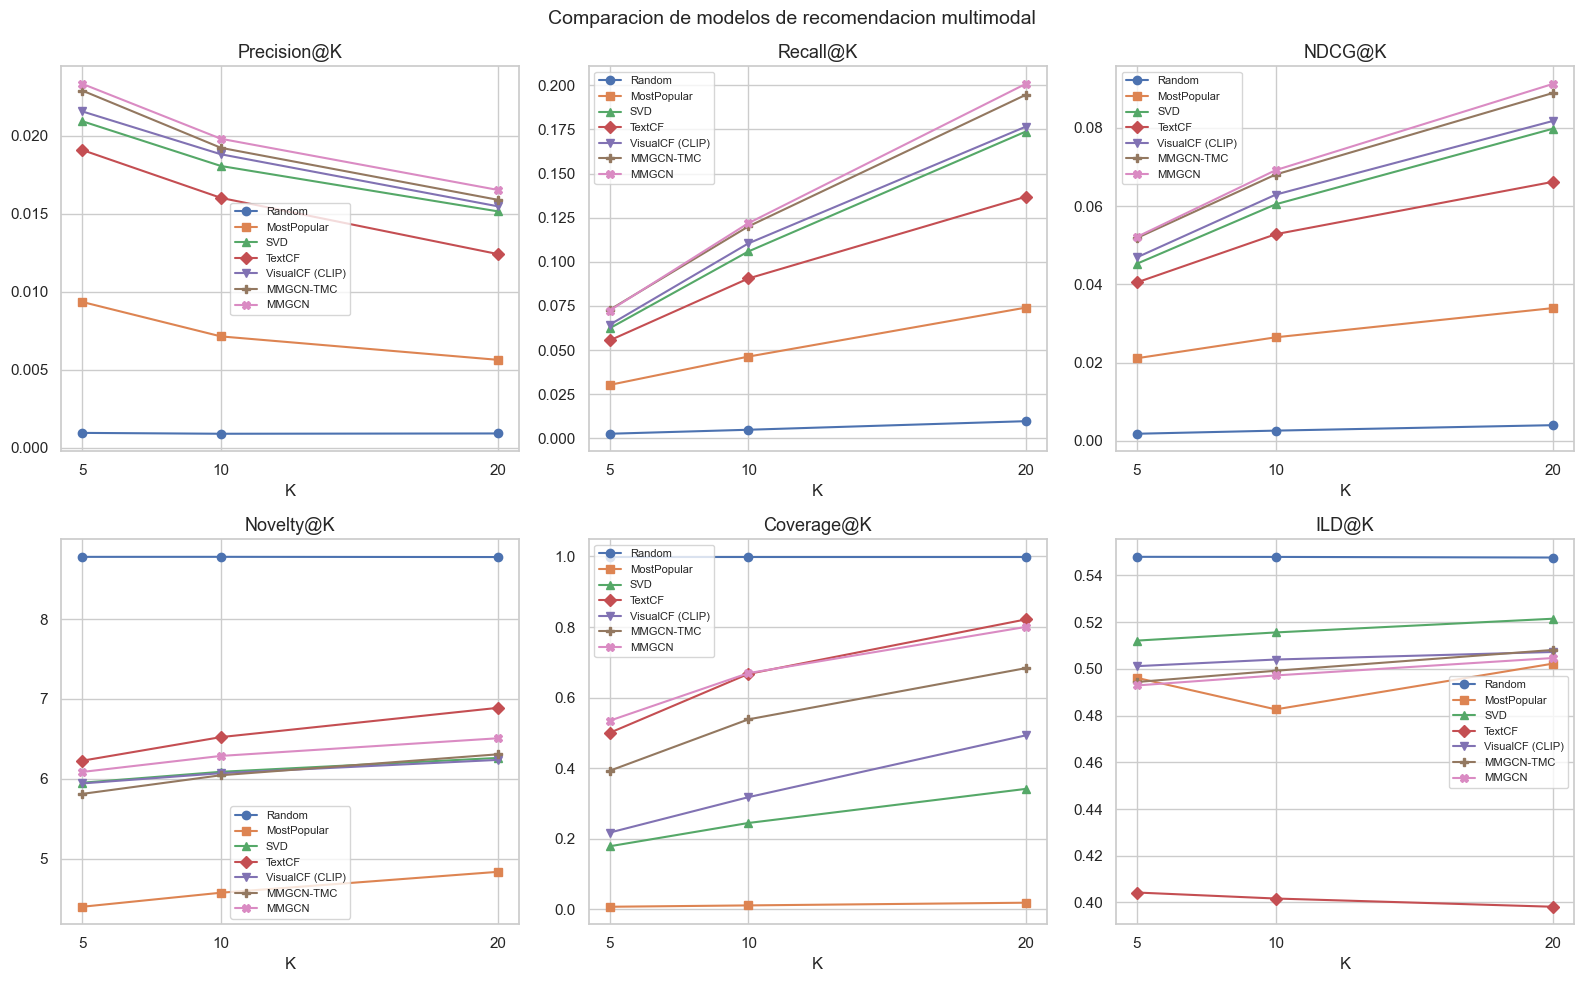

In [9]:
import math

# accuracy: precision/recall/ndcg (bajan con K) | beyond-accuracy: novelty/coverage/ild (suben con K)
metric_cols = [c for c in ['precision', 'recall', 'ndcg', 'novelty', 'coverage', 'ild']
               if any(c in df.columns for df in all_metrics.values())]
titles = {'precision': 'Precision@K', 'recall': 'Recall@K', 'ndcg': 'NDCG@K',
          'novelty': 'Novelty@K', 'coverage': 'Coverage@K', 'ild': 'ILD@K'}
styles = ['-o', '-s', '-^', '-D', '-v', '-P', '-X']

ncols = 3
nrows = math.ceil(len(metric_cols) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
axes = axes.flatten()

for ax, col in zip(axes, metric_cols):
    for (name, df), style in zip(all_metrics.items(), styles):
        if col in df.columns:
            ax.plot(df.index, df[col], style, label=name, linewidth=1.5, markersize=6)
    ax.set_title(titles[col], fontsize=13)
    ax.set_xlabel('K')
    ax.set_xticks(K_VALUES)
    ax.legend(fontsize=8)

for ax in axes[len(metric_cols):]:
    ax.set_visible(False)

plt.suptitle('Comparacion de modelos de recomendacion multimodal', fontsize=14)
plt.tight_layout()
plt.savefig('../results/comparison.png', dpi=150, bbox_inches='tight')
print('Figura guardada: results/comparison.png')

## 4. Configs de cada modelo

In [10]:
for model in MODELS:
    config_path = os.path.join(RESULTS_BASE, model, 'config.json')
    if os.path.exists(config_path):
        with open(config_path) as f:
            print(json.dumps(json.load(f), indent=2))
        print()

{
  "model": "SVD",
  "n_factors": 50,
  "random_state": 42,
  "library": "sklearn.decomposition.TruncatedSVD"
}

{
  "model": "TextCF",
  "alpha": 0.5,
  "n_factors": 50,
  "sbert_model": "all-MiniLM-L6-v2",
  "like_threshold": 4.0
}

{
  "model": "VisualCF",
  "alpha": 0.5,
  "n_factors": 50,
  "image_model": "CLIP (512d)",
  "like_threshold": 4.0
}

{
  "model": "MMGCN_TMC",
  "embed_dim": 64,
  "dim_latent_v": 256,
  "evidence_dim": 16,
  "aggr_mode": "mean",
  "concate": false,
  "has_id": true,
  "epochs": 150,
  "lr": 0.0001,
  "weight_decay": 1e-05,
  "_kl": 0.1,
  "annealing_step": 10,
  "batch_size": 1024,
  "like_threshold": 4.0,
  "image_model": "CLIP (512d)",
  "text_model": "all-MiniLM-L6-v2",
  "loss": "BPR + KL-DS + L2 reg",
  "fusion": "Dempster-Shafer (TMC, Han et al. TPAMI 2023)",
  "fusion_ref": "DOI: 10.1109/TPAMI.2022.3171983",
  "gcn_layers": 3,
  "n_items_multimodal": 1830,
  "n_users": 18117
}

{
  "model": "MMGCN",
  "embed_dim": 64,
  "dim_latent_v": 256,
  "